Install packages

In [ ]:
!pip install -q transformers datasets accelerate peft bitsandbytes sentencepiece openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.5 MB/s eta 0:00:00


Login to Hugging Face

In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Upload and load dataset

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

train_df = pd.read_excel("train.xlsx")
test_df = pd.read_excel("test.xlsx")

if "text" not in train_df.columns:
    train_df.rename(columns={train_df.columns[0]: "text"}, inplace=True)

if "text" not in test_df.columns:
    test_df.rename(columns={test_df.columns[0]: "text"}, inplace=True)

print("\n=== TRAIN DATA SAMPLE ===")
print(train_df.head())

print("\n=== SAMPLE TEXT ===")
for i in range(min(3, len(train_df))):
    print(train_df["text"].iloc[i])

Saving test.xlsx to test.xlsx
Saving train.xlsx to train.xlsx

=== TRAIN DATA SAMPLE ===
                                                text
0  Name: John | ID: 1001 | Role: Student | Action...
1  Name: Mary | ID: 1002 | Role: Admin | Action: ...
2  Name: Alex | ID: 1003 | Role: Student | Action...
3  Name: Sara | ID: 1004 | Role: Staff | Action: ...
4  Name: David | ID: 1005 | Role: Student | Actio...

=== SAMPLE TEXT ===
Name: John | ID: 1001 | Role: Student | Action: Login
Name: Mary | ID: 1002 | Role: Admin | Action: Upload
Name: Alex | ID: 1003 | Role: Student | Action: Download


Load LLaMA-2 tokenizer and model

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "meta-llama/Llama-2-7b-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

base_model.config.pad_token_id = tokenizer.pad_token_id

config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

Show tokenization sample

In [ ]:
example_text = train_df["text"].iloc[0]

tokens = tokenizer.tokenize(example_text)
encoded = tokenizer(
    example_text,
    truncation=True,
    padding="max_length",
    max_length=64
)

print("\n=== TOKENIZATION SAMPLE ===")
print("Original Text:\n", example_text)
print("\nTokens:\n", tokens)
print("\nInput IDs (first 20):\n", encoded["input_ids"][:20])
print("\nAttention Mask (first 20):\n", encoded["attention_mask"][:20])


=== TOKENIZATION SAMPLE ===
Original Text:
 Name: John | ID: 1001 | Role: Student | Action: Login

Tokens:
 ['▁Name', ':', '▁John', '▁|', '▁ID', ':', '▁', '1', '0', '0', '1', '▁|', '▁Ro', 'le', ':', '▁Student', '▁|', '▁Action', ':', '▁Login']

Input IDs (first 20):
 [1, 4408, 29901, 2259, 891, 3553, 29901, 29871, 29896, 29900, 29900, 29896, 891, 1528, 280, 29901, 15740, 891, 9123, 29901]

Attention Mask (first 20):
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Apply LoRA

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 4,194,304 || all params: 6,742,609,920 || trainable%: 0.0622


Training function

In [ ]:
from datasets import Dataset
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

def train_model(df, model):
    dataset = Dataset.from_pandas(df[["text"]])

    def tokenize(example):
        return tokenizer(
            example["text"],
            truncation=True,
            padding="max_length",
            max_length=64
        )

    dataset = dataset.map(tokenize, batched=True)
    dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False
    )

    training_args = TrainingArguments(
        output_dir="./llama2_model",
        num_train_epochs=3,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        fp16=True,
        logging_steps=10,
        save_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        data_collator=data_collator
    )

    trainer.train()
    return model

Compute loss

In [ ]:
import numpy as np

def compute_losses(model, df):
    model.eval()
    losses = []

    for i, text in enumerate(df["text"]):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=64
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs, labels=inputs["input_ids"])

        loss = outputs.loss.item()
        losses.append(loss)

        if i < 3:
            print("\nText:", text)
            print("Loss:", loss)

    return losses

Membership inference metrics

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

def evaluate(train_losses, test_losses):
    threshold = (np.mean(train_losses) + np.mean(test_losses)) / 2

    y_true = [1] * len(train_losses) + [0] * len(test_losses)
    y_pred = [(loss < threshold) for loss in (train_losses + test_losses)]

    ASR = accuracy_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    FPR = fp / (fp + tn)

    avg_loss = np.mean(test_losses)

    return ASR, FPR, avg_loss

Run baseline experiment

In [ ]:
print("\n=== LLAMA-2 BASELINE ===")

model = train_model(train_df, model)

print("\n--- TRAIN LOSSES ---")
train_losses = compute_losses(model, train_df)

print("\n--- TEST LOSSES ---")
test_losses = compute_losses(model, test_df)

ASR, FPR, loss = evaluate(train_losses, test_losses)

print("\n=== FINAL RESULTS ===")
print("ASR:", ASR)
print("FPR:", FPR)
print("Average Loss:", loss)


=== LLAMA-2 BASELINE ===


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss



--- TRAIN LOSSES ---

Text: Name: John | ID: 1001 | Role: Student | Action: Login
Loss: 16.154251098632812

Text: Name: Mary | ID: 1002 | Role: Admin | Action: Upload
Loss: 15.745716094970703

Text: Name: Alex | ID: 1003 | Role: Student | Action: Download
Loss: 16.314359664916992

--- TEST LOSSES ---

Text: Name: Henry | ID: 2001 | Role: Student | Action: Login
Loss: 16.645259857177734

Text: Name: Evelyn | ID: 2002 | Role: Admin | Action: Upload
Loss: 15.846243858337402

Text: Name: Alexander | ID: 2003 | Role: Student | Action: Download
Loss: 16.391353607177734

=== FINAL RESULTS ===
ASR: 0.55
FPR: 0.4
Average Loss: 16.211063289642333


# Implementing Defence (Sanitisation, Augmentation and DP)

**Sanitisation**

Apply Sanitisation

In [ ]:
import re

def sanitise(text):
    text = re.sub(r"Name:\s*[^|]+", "Name: [REDACTED]", text)
    text = re.sub(r"ID:\s*\d+", "ID: [REDACTED]", text)
    return text

train_df_san = train_df.copy()
test_df_san = test_df.copy()

train_df_san["text"] = train_df_san["text"].apply(sanitise)
test_df_san["text"] = test_df_san["text"].apply(sanitise)

print("\n=== SANITISATION SAMPLE ===")
print("Original :", train_df["text"].iloc[0])
print("Sanitised:", train_df_san["text"].iloc[0])


=== SANITISATION SAMPLE ===
Original : Name: John | ID: 1001 | Role: Student | Action: Login
Sanitised: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Login


Train + Evaluate

In [ ]:
print("\n=== SANITISATION MODEL ===")

san_model = train_model(train_df_san, model)

print("\n--- TRAIN LOSSES ---")
train_losses_san = compute_losses(san_model, train_df_san)

print("\n--- TEST LOSSES ---")
test_losses_san = compute_losses(san_model, test_df_san)

ASR_san, FPR_san, loss_san = evaluate(train_losses_san, test_losses_san)

print("\n--- SANITISATION RESULTS ---")
print("ASR:", ASR_san)
print("FPR:", FPR_san)
print("Average Loss:", loss_san)


=== SANITISATION MODEL ===


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss



--- TRAIN LOSSES ---

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Login
Loss: 15.013555526733398

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Admin | Action: Upload
Loss: 14.310990333557129

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Download
Loss: 14.831957817077637

--- TEST LOSSES ---

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Login
Loss: 15.013555526733398

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Admin | Action: Upload
Loss: 14.310990333557129

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Download
Loss: 14.831957817077637

--- SANITISATION RESULTS ---
ASR: 0.5
FPR: 0.6
Average Loss: 14.528455448150634


**Augmentation**

Create augmented data

In [ ]:
def augment_text(text):
    text = text.replace("Login", "Sign-in")
    text = text.replace("Upload", "Send")
    text = text.replace("Download", "Retrieve")
    text = text.replace("Delete", "Remove")
    text = text.replace("View", "Access")
    return text

train_df_aug = train_df.copy()
train_df_aug["aug_text"] = train_df_aug["text"].apply(augment_text)

print("\n=== AUGMENTATION SAMPLE ===")
print("Original :", train_df["text"].iloc[2])
print("Augmented:", train_df_aug["aug_text"].iloc[2])


=== AUGMENTATION SAMPLE ===
Original : Name: Alex | ID: 1003 | Role: Student | Action: Download
Augmented: Name: Alex | ID: 1003 | Role: Student | Action: Retrieve


Combine original + augmented

In [ ]:
train_augmented = pd.concat(
    [
        train_df[["text"]],
        train_df_aug[["aug_text"]].rename(columns={"aug_text": "text"})
    ],
    ignore_index=True
)

print("Total samples after augmentation:", len(train_augmented))

Total samples after augmentation: 20


Train + evaluate

In [ ]:
print("\n=== AUGMENTATION MODEL ===")

aug_model = train_model(train_augmented, model)

print("\n--- TRAIN LOSSES ---")
train_losses_aug = compute_losses(aug_model, train_df)

print("\n--- TEST LOSSES ---")
test_losses_aug = compute_losses(aug_model, test_df)

ASR_aug, FPR_aug, loss_aug = evaluate(train_losses_aug, test_losses_aug)

print("\n--- AUGMENTATION RESULTS ---")
print("ASR:", ASR_aug)
print("FPR:", FPR_aug)
print("Average Loss:", loss_aug)


=== AUGMENTATION MODEL ===


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss



--- TRAIN LOSSES ---

Text: Name: John | ID: 1001 | Role: Student | Action: Login
Loss: 16.809356689453125

Text: Name: Mary | ID: 1002 | Role: Admin | Action: Upload
Loss: 16.850025177001953

Text: Name: Alex | ID: 1003 | Role: Student | Action: Download
Loss: 17.286725997924805

--- TEST LOSSES ---

Text: Name: Henry | ID: 2001 | Role: Student | Action: Login
Loss: 17.453346252441406

Text: Name: Evelyn | ID: 2002 | Role: Admin | Action: Upload
Loss: 16.885543823242188

Text: Name: Alexander | ID: 2003 | Role: Student | Action: Download
Loss: 17.241168975830078

--- AUGMENTATION RESULTS ---
ASR: 0.6
FPR: 0.3
Average Loss: 17.135119819641112


Differential Privacy (DP)

Add noise

In [ ]:
import random

def add_noise(text):
    words = text.split()

    for i in range(len(words)):
        if random.random() < 0.3:   # 30% noise
            words[i] = "[NOISE]"

    return " ".join(words)

train_df_dp = train_df.copy()
train_df_dp["text"] = train_df_dp["text"].apply(add_noise)

print("\n=== DP SAMPLE ===")
print("Original :", train_df["text"].iloc[2])
print("Noisy    :", train_df_dp["text"].iloc[2])


=== DP SAMPLE ===
Original : Name: Alex | ID: 1003 | Role: Student | Action: Download
Noisy    : Name: [NOISE] | ID: [NOISE] [NOISE] Role: Student | Action: Download


Train + evaluate

In [ ]:
print("\n=== DP MODEL ===")

dp_model = train_model(train_df_dp, model)

train_losses_dp = compute_losses(dp_model, train_df_dp)
test_losses_dp = compute_losses(dp_model, test_df)

ASR_dp, FPR_dp, loss_dp = evaluate(train_losses_dp, test_losses_dp)

print("\n--- DP RESULTS ---")
print("ASR:", ASR_dp)
print("FPR:", FPR_dp)
print("Average Loss:", loss_dp)


=== DP MODEL ===


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss



Text: Name: [NOISE] [NOISE] [NOISE] 1001 | Role: [NOISE] | [NOISE] [NOISE]
Loss: 7.76402473449707

Text: Name: [NOISE] [NOISE] ID: 1002 [NOISE] Role: Admin [NOISE] Action: Upload
Loss: 11.654966354370117

Text: Name: [NOISE] | ID: [NOISE] [NOISE] Role: Student | Action: Download
Loss: 14.890950202941895

Text: Name: Henry | ID: 2001 | Role: Student | Action: Login
Loss: 17.498764038085938

Text: Name: Evelyn | ID: 2002 | Role: Admin | Action: Upload
Loss: 16.606388092041016

Text: Name: Alexander | ID: 2003 | Role: Student | Action: Download
Loss: 17.182645797729492

--- DP RESULTS ---
ASR: 0.9
FPR: 0.0
Average Loss: 17.036515045166016


**Final Comparison**

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["ASR", "FPR", "Average Loss"],
    "Baseline": [ASR, FPR, loss],
    "Sanitisation": [ASR_san, FPR_san, loss_san],
    "Augmentation": [ASR_aug, FPR_aug, loss_aug],
    "DP": [ASR_dp, FPR_dp, loss_dp]
})

print("\n=== FINAL COMPARISON ===")
print(results)


=== FINAL COMPARISON ===
         Metric   Baseline  Sanitisation  Augmentation         DP
0           ASR   0.550000      0.500000       0.60000   0.900000
1           FPR   0.400000      0.600000       0.30000   0.000000
2  Average Loss  16.211063     14.528455      17.13512  17.036515


**ASR Graph Comparison**

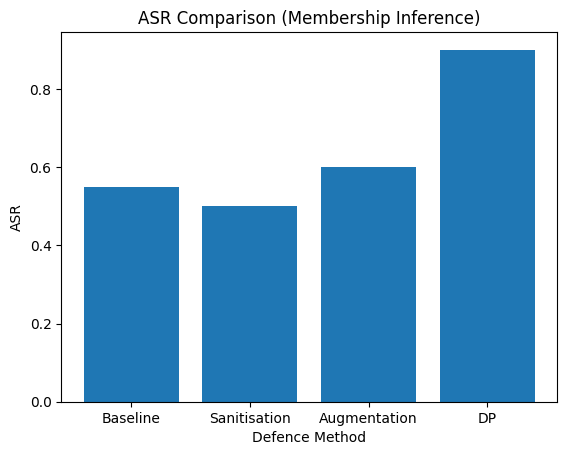

In [ ]:
import matplotlib.pyplot as plt

labels = ["Baseline", "Sanitisation", "Augmentation", "DP"]
ASR_values = [ASR, ASR_san, ASR_aug, ASR_dp]

plt.figure()
plt.bar(labels, ASR_values)

plt.title("ASR Comparison (Membership Inference)")
plt.xlabel("Defence Method")
plt.ylabel("ASR")

plt.show()